# Notebook for the Gender Subgroup Analysis

#### Imports

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#### Data Visualisation

In [4]:
# Read Data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')

df_male = data[data["Gender"] == 1]         # Male
df_female = data[data["Gender"] == 2]       # Female

print(df_male.shape)
print(df_female.shape)

(2876, 168)
(3246, 168)


## Gender Subgroups

How happy are you? - Mean value between the genders

Scale 1-10 (1 lowest - 10 highest level of happiness)

In [4]:
data.groupby("Gender")["How happy are you?"].mean()

Gender
1    7.686370
2    7.647258
Name: How happy are you?, dtype: float64

In [8]:
data.groupby("Gender")["How happy are you?"].value_counts()

Gender  How happy are you?
1       8                     870
        7                     534
        9                     524
        10                    393
        6                     240
        5                     177
        4                      70
        3                      32
        2                      25
        1                      11
2       8                     909
        9                     593
        7                     563
        10                    491
        6                     269
        5                     250
        4                      62
        3                      57
        2                      28
        1                      24
Name: count, dtype: int64

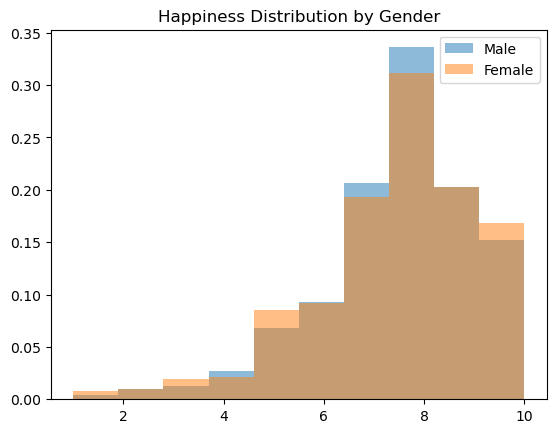

In [6]:
plt.hist(df_male["How happy are you?"], alpha=0.5, label="Male", density=True)
plt.hist(df_female["How happy are you?"], alpha=0.5, label="Female", density=True)
plt.legend()
plt.title("Happiness Distribution by Gender")
plt.show()

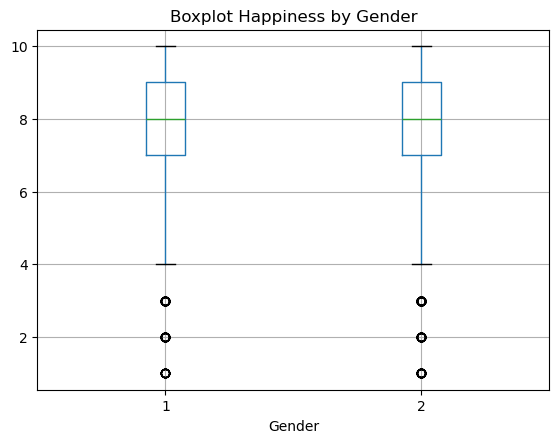

In [8]:
data.boxplot(column="How happy are you?", by="Gender")
plt.title("Boxplot Happiness by Gender")
plt.suptitle("")
plt.show()

## Model Training

In [9]:
import importlib
from XGBoost import xgboost_machine_learning
importlib.reload(xgboost_machine_learning)

<module 'XGBoost.xgboost_machine_learning' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\XGBoost\\xgboost_machine_learning.py'>

Model Settings

In [10]:
my_target_column = "How happy are you?"
my_test_size = 0.2
my_random_state = 42

# Model-specific hyperparameters (baseline defaults)
my_n_estimators = 100
my_max_depth = None

# SHAP settings
my_number_of_shaply_rows = 5000
my_number_header_rows = 150

#### Set boolean to True if you want to train the model for the female subgroup, for male subgroup set to False

Run model training and shap

In [15]:
is_female = False

if is_female:
    data = df_female
else:
    data = df_male

In [16]:
my_target_column = 'How happy are you?'
print("Shape before: ", data.shape)

# Drop 'How satisfied with...' columns
# They have too much predictive value and there are similar questions
# e.g. "Health condition", "Quality of education system?", "Feel left out of sociey?"
columns_to_remove = [
    'How satisfied with present standard of living?',
    'How satisfied with family life?',
    'How satisfied with social life?',
    'How satisfied with health?',
    'How satisfied with economic situation in the country?',
    'How satisfied with accommodation?',
    'How satisfied with education?'
]
data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print("Shape after: ", data.shape)

model_1B, shap_results_1B = xgboost_machine_learning.run_xgb_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    cv_folds=3,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)

Shape before:  (2876, 168)
Shape after:  (2876, 161)
Fitting 3 folds for each of 108 candidates, totalling 324 fits

 Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
 Test RMSE: 1.3889
 Test R²: 0.3352
Starting SHAP for 5000 rows...


100%|██████████| 576/576 [00:11<00:00, 51.00it/s]


Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.180359   0.002733
115  I generally feel that what I do in life is wor...  0.147238  -0.010597
94   Can't find the way because life has become so ...  0.133691  -0.003399
113  Deprivation index: No. of items hhold can't af...  0.112975   0.002260
61                     Quality of child care services?  0.100524  -0.002432
..                                                 ...       ...        ...
68           Child care used in 12 months - don't know  0.000000   0.000000
74          Long term care used in 12 months - refusal  0.000000   0.000000
73       Long term care used in 12 months - don't know  0.000000   0.000000
127                                    Country_Belgium  0.000000   0.000000
109           Payments for consumer loans/credit cards  0.000000   0.000000

[150 rows x 3 columns]


In [17]:
# Save results
if is_female:
    shap_results_1B.to_csv("Results/female_shap_results_1B_optimized.csv", index=False)
else:
    shap_results_1B.to_csv("Results/male_shap_results_1B_optimized.csv", index=False)

### Plot Results

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

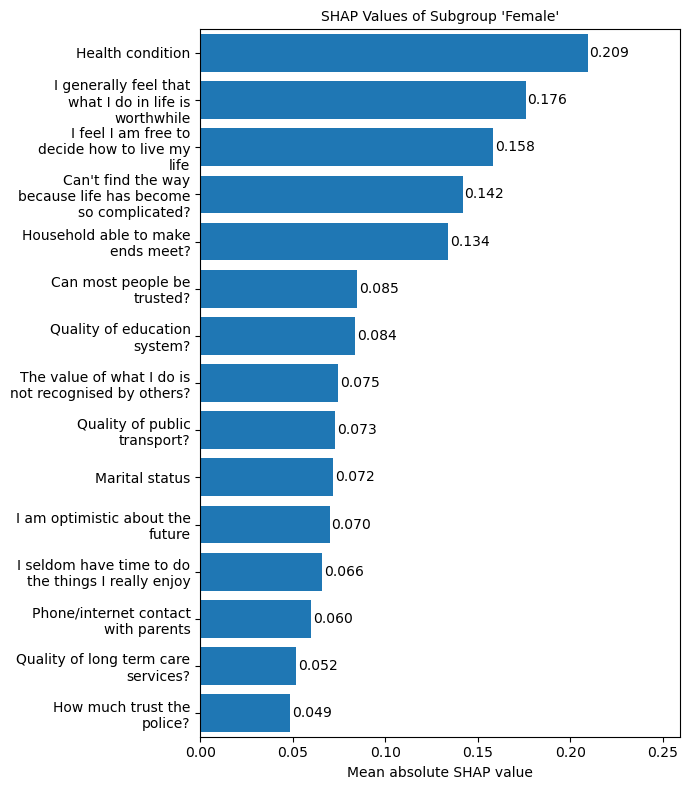

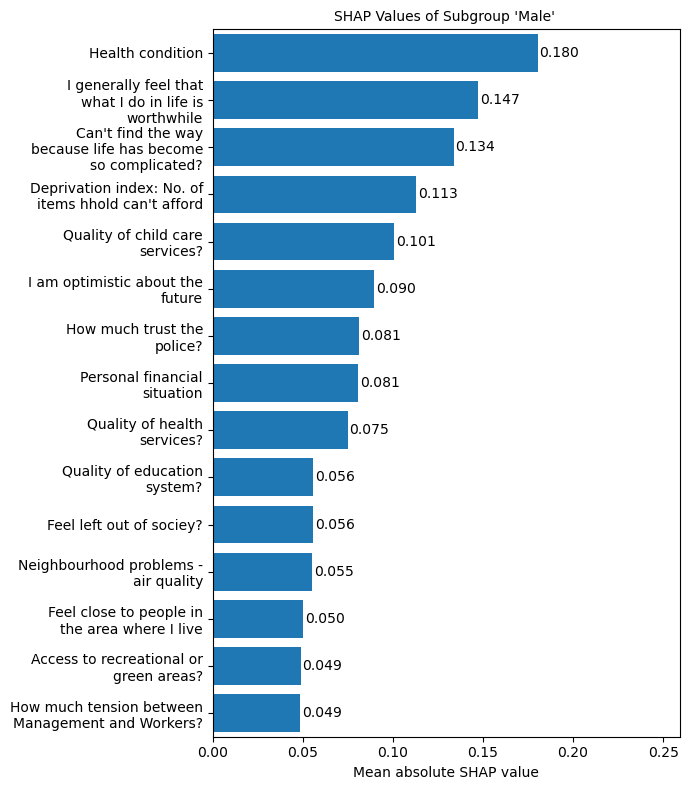

In [12]:
# Load Data
df_female = pd.read_csv("Results/female_shap_results_1B_optimized.csv")
df_male = pd.read_csv("Results/male_shap_results_1B_optimized.csv")

def plot_shap_large(df, title, max_questions=None):

    # # Summarize countries in to one group
    # country_mask = df["Questions"].str.contains("Country_")
    # country_total = df.loc[country_mask, "Value"].sum()
    # # Alle Country_* Zeilen entfernen
    # df = df.loc[~country_mask].copy()
    # df = pd.concat([
    #     df,
    #     pd.DataFrame([{
    #         "Questions": "Country Effects",
    #         "Value": country_total,
    #         "Direction": 0  # optional
    #     }])
    # ], ignore_index=True)
    #
    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    #plt.figure(figsize=(5.5, n * 0.6))
    plt.figure(figsize=(7, 8))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_female["Value"].max(),
        df_male["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)

    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_female, "SHAP Values of Subgroup 'Female'", max_questions=15)
plot_shap_large(df_male, "SHAP Values of Subgroup 'Male' ", max_questions=15)
plt.show()